In [1]:
# Cell 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
import warnings
warnings.filterwarnings('ignore')

print("✅ Libraries imported successfully!")

✅ Libraries imported successfully!


In [2]:
# Cell 2: Load Clean Dataset
df = pd.read_csv('../../data/processed/creditcard_clean.csv')

print("✅ Clean dataset loaded!")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")

✅ Clean dataset loaded!
Shape: (283726, 33)
Columns: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount', 'Class', 'Hour', 'Hour_int']


In [3]:
# Cell 3: Feature Engineering
print("=" * 50)
print("FEATURE ENGINEERING")
print("=" * 50)

# 1. Time-based features
df['Hour'] = (df['Time'] / 3600) % 24
df['Is_Night'] = ((df['Hour'] >= 22) | (df['Hour'] <= 6)).astype(int)
df['Is_Dawn'] = ((df['Hour'] >= 1) | (df['Hour'] <= 5)).astype(int)

# 2. Amount-based features
df['Amount_log'] = np.log1p(df['Amount'])
df['Is_Zero_Amount'] = (df['Amount'] == 0).astype(int)
df['Is_Large_Amount'] = (df['Amount'] > 1000).astype(int)

# 3. Amount bins
df['Amount_Bin'] = pd.cut(df['Amount'], 
                           bins=[0, 10, 50, 200, 1000, 99999],
                           labels=[0, 1, 2, 3, 4],
                           include_lowest=True).astype(int)

# Drop columns we don't need
df = df.drop(['Hour_int'], axis=1)

print("New features created:")
print("  ✅ Is_Night    - Transaction at night (10PM-6AM)")
print("  ✅ Is_Dawn     - Transaction at dawn (1AM-5AM)")
print("  ✅ Amount_log  - Log transformed amount")
print("  ✅ Is_Zero_Amount - Zero value transactions")
print("  ✅ Is_Large_Amount - Transactions over $1000")
print("  ✅ Amount_Bin  - Amount category (0-4)")

print(f"\nDataset shape: {df.shape}")
print(f"Total features: {df.shape[1] - 1} (excluding Class)")

# Quick check
print("\nNew features sample:")
print(df[['Amount', 'Amount_log', 'Amount_Bin', 
          'Hour', 'Is_Night', 'Is_Dawn', 
          'Is_Zero_Amount', 'Is_Large_Amount']].head())

FEATURE ENGINEERING
New features created:
  ✅ Is_Night    - Transaction at night (10PM-6AM)
  ✅ Is_Dawn     - Transaction at dawn (1AM-5AM)
  ✅ Amount_log  - Log transformed amount
  ✅ Is_Zero_Amount - Zero value transactions
  ✅ Is_Large_Amount - Transactions over $1000
  ✅ Amount_Bin  - Amount category (0-4)

Dataset shape: (283726, 38)
Total features: 37 (excluding Class)

New features sample:
   Amount  Amount_log  Amount_Bin      Hour  Is_Night  Is_Dawn  \
0  149.62    5.014760           2  0.000000         1        1   
1    2.69    1.305626           0  0.000000         1        1   
2  378.66    5.939276           3  0.000278         1        1   
3  123.50    4.824306           2  0.000278         1        1   
4   69.99    4.262539           2  0.000556         1        1   

   Is_Zero_Amount  Is_Large_Amount  
0               0                0  
1               0                0  
2               0                0  
3               0                0  
4               0 

In [4]:
# Cell 4: Feature Scaling
print("=" * 50)
print("FEATURE SCALING")
print("=" * 50)

# We use RobustScaler because it's resistant to outliers
# It scales based on median and IQR instead of mean and std

scaler = RobustScaler()

# Only scale Time and Amount (V1-V28 are already scaled by PCA)
cols_to_scale = ['Time', 'Amount', 'Amount_log']

df_scaled = df.copy()
df_scaled[cols_to_scale] = scaler.fit_transform(df[cols_to_scale])

print("Scaled columns using RobustScaler:")
for col in cols_to_scale:
    print(f"  ✅ {col}")

print("\nBefore scaling (Amount stats):")
print(f"  Mean:  {df['Amount'].mean():.4f}")
print(f"  Std:   {df['Amount'].std():.4f}")
print(f"  Min:   {df['Amount'].min():.4f}")
print(f"  Max:   {df['Amount'].max():.4f}")

print("\nAfter scaling (Amount stats):")
print(f"  Mean:  {df_scaled['Amount'].mean():.4f}")
print(f"  Std:   {df_scaled['Amount'].std():.4f}")
print(f"  Min:   {df_scaled['Amount'].min():.4f}")
print(f"  Max:   {df_scaled['Amount'].max():.4f}")

print("\n✅ Scaling complete!")

FEATURE SCALING
Scaled columns using RobustScaler:
  ✅ Time
  ✅ Amount
  ✅ Amount_log

Before scaling (Amount stats):
  Mean:  88.4727
  Std:   250.3994
  Min:   0.0000
  Max:   25691.1600

After scaling (Amount stats):
  Mean:  0.9244
  Std:   3.4821
  Min:   -0.3059
  Max:   356.9623

✅ Scaling complete!


In [5]:
# Cell 5: Train/Validation/Test Split
print("=" * 50)
print("TRAIN/VALIDATION/TEST SPLIT")
print("=" * 50)

# Separate features and target
X = df_scaled.drop(['Class'], axis=1)
y = df_scaled['Class']

print(f"Features (X): {X.shape}")
print(f"Target (y):   {y.shape}")
print(f"Fraud cases:  {y.sum()} ({y.mean()*100:.4f}%)")

# First split: 85% train+val, 15% test
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, 
    test_size=0.15, 
    random_state=42, 
    stratify=y  # Important: maintains fraud ratio in each split
)

# Second split: 70% train, 15% validation
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp,
    test_size=0.1765,  # 0.1765 * 0.85 = 0.15
    random_state=42,
    stratify=y_temp
)

print("\n" + "=" * 50)
print("SPLIT RESULTS:")
print("=" * 50)
print(f"Training set:   {X_train.shape[0]:,} rows ({X_train.shape[0]/len(X)*100:.1f}%)")
print(f"  Fraud:        {y_train.sum()} ({y_train.mean()*100:.4f}%)")
print(f"Validation set: {X_val.shape[0]:,} rows ({X_val.shape[0]/len(X)*100:.1f}%)")
print(f"  Fraud:        {y_val.sum()} ({y_val.mean()*100:.4f}%)")
print(f"Test set:       {X_test.shape[0]:,} rows ({X_test.shape[0]/len(X)*100:.1f}%)")
print(f"  Fraud:        {y_test.sum()} ({y_test.mean()*100:.4f}%)")

print("\n✅ Stratified split complete!")
print("✅ Fraud ratio maintained across all splits!")

TRAIN/VALIDATION/TEST SPLIT
Features (X): (283726, 37)
Target (y):   (283726,)
Fraud cases:  473 (0.1667%)

SPLIT RESULTS:
Training set:   198,601 rows (70.0%)
  Fraud:        331 (0.1667%)
Validation set: 42,566 rows (15.0%)
  Fraud:        71 (0.1668%)
Test set:       42,559 rows (15.0%)
  Fraud:        71 (0.1668%)

✅ Stratified split complete!
✅ Fraud ratio maintained across all splits!


HANDLING CLASS IMBALANCE WITH SMOTE
What is SMOTE?
  Synthetic Minority Oversampling Technique
  Creates synthetic fraud samples by interpolating
  between existing fraud cases
  Applied ONLY to training data (never test/val!)

Before SMOTE:
  Training samples:  198,601
  Legitimate:        198,270
  Fraud:             331
  Ratio:             599:1

After SMOTE:
  Training samples:  396,540
  Legitimate:        198,270
  Fraud:             198,270
  Ratio:             1:1


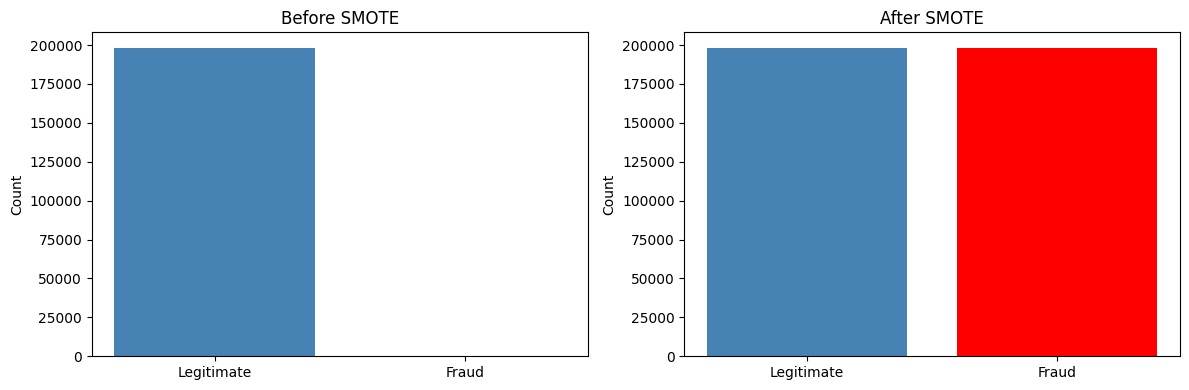


✅ SMOTE applied successfully!


In [6]:
# Cell 6: Apply SMOTE to Training Data Only
print("=" * 50)
print("HANDLING CLASS IMBALANCE WITH SMOTE")
print("=" * 50)

print("What is SMOTE?")
print("  Synthetic Minority Oversampling Technique")
print("  Creates synthetic fraud samples by interpolating")
print("  between existing fraud cases")
print("  Applied ONLY to training data (never test/val!)\n")

print("Before SMOTE:")
print(f"  Training samples:  {len(X_train):,}")
print(f"  Legitimate:        {(y_train==0).sum():,}")
print(f"  Fraud:             {(y_train==1).sum():,}")
print(f"  Ratio:             {(y_train==0).sum()/(y_train==1).sum():.0f}:1")

# Apply SMOTE
smote = SMOTE(random_state=42, k_neighbors=5)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print("\nAfter SMOTE:")
print(f"  Training samples:  {len(X_train_smote):,}")
print(f"  Legitimate:        {(y_train_smote==0).sum():,}")
print(f"  Fraud:             {(y_train_smote==1).sum():,}")
print(f"  Ratio:             {(y_train_smote==0).sum()/(y_train_smote==1).sum():.0f}:1")

# Visualize
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].bar(['Legitimate', 'Fraud'], 
            [(y_train==0).sum(), (y_train==1).sum()],
            color=['steelblue', 'red'])
axes[0].set_title('Before SMOTE')
axes[0].set_ylabel('Count')

axes[1].bar(['Legitimate', 'Fraud'],
            [(y_train_smote==0).sum(), (y_train_smote==1).sum()],
            color=['steelblue', 'red'])
axes[1].set_title('After SMOTE')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.savefig('../../docs/smote_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n✅ SMOTE applied successfully!")

In [7]:
# Cell 7: Save Processed Data
print("=" * 50)
print("SAVING PROCESSED DATA")
print("=" * 50)

import pickle

# Save datasets as CSV
X_train_smote.to_csv('../../data/processed/X_train.csv', index=False)
y_train_smote.to_csv('../../data/processed/y_train.csv', index=False)

X_val.to_csv('../../data/processed/X_val.csv', index=False)
y_val.to_csv('../../data/processed/y_val.csv', index=False)

X_test.to_csv('../../data/processed/X_test.csv', index=False)
y_test.to_csv('../../data/processed/y_test.csv', index=False)

# Save scaler for later use in deployment
with open('../../models/saved_models/scaler.pkl', 'wb') as f:
    pickle.dump(scaler, f)

print("✅ Saved: X_train.csv  (396,540 rows - SMOTE balanced)")
print("✅ Saved: y_train.csv  (396,540 rows - SMOTE balanced)")
print("✅ Saved: X_val.csv    (42,566 rows)")
print("✅ Saved: y_val.csv    (42,566 rows)")
print("✅ Saved: X_test.csv   (42,559 rows)")
print("✅ Saved: y_test.csv   (42,559 rows)")
print("✅ Saved: scaler.pkl   (RobustScaler for deployment)")

print("\n" + "=" * 50)
print("PREPROCESSING SUMMARY")
print("=" * 50)
print("""
Steps Completed:
  ✅ Loaded clean dataset (283,726 rows)
  ✅ Engineered 7 new features
  ✅ Scaled Time, Amount, Amount_log
  ✅ Split data 70/15/15 (stratified)
  ✅ Applied SMOTE to training data only
  ✅ Saved all datasets to data/processed/
  ✅ Saved scaler to models/saved_models/

Ready for Phase 4: Model Development!
""")

SAVING PROCESSED DATA
✅ Saved: X_train.csv  (396,540 rows - SMOTE balanced)
✅ Saved: y_train.csv  (396,540 rows - SMOTE balanced)
✅ Saved: X_val.csv    (42,566 rows)
✅ Saved: y_val.csv    (42,566 rows)
✅ Saved: X_test.csv   (42,559 rows)
✅ Saved: y_test.csv   (42,559 rows)
✅ Saved: scaler.pkl   (RobustScaler for deployment)

PREPROCESSING SUMMARY

Steps Completed:
  ✅ Loaded clean dataset (283,726 rows)
  ✅ Engineered 7 new features
  ✅ Scaled Time, Amount, Amount_log
  ✅ Split data 70/15/15 (stratified)
  ✅ Applied SMOTE to training data only
  ✅ Saved all datasets to data/processed/
  ✅ Saved scaler to models/saved_models/

Ready for Phase 4: Model Development!

